# Lista 02 - Estatística

**Questão 01 - Usando o mesmo portfolio da sua lista anterior, normalize os retornos logarítmicos,( z-score). O que ele significa?**

In [13]:
### Escreva aqui seu código para responder a questão 1.
### Para responder a parte interpretativa, crie uma nova célula de texto!

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import norm, skew, kurtosis, t
df = pd.read_excel(
    "./Economatica-q1.xlsx",
    skiprows=3,
    index_col=0,
)

df.index = pd.to_datetime(df.index, dayfirst=True)

df = df.apply(pd.to_numeric, errors="coerce").dropna()
df2 = df.copy().dropna()
tickers = ['ABEV3', 'BBDC4', 'EMBJ3', 'PETR4', 'VALE3', 'IBOV']
log_return = np.log(df).diff().dropna()
for ticker in tickers:
    med = log_return[ticker].mean()
    std = log_return[ticker].std()
    df2['z_score' + ticker] = (log_return[ticker] - med) / std
    print(df2['z_score' + ticker].head())


Data
2017-01-02         NaN
2017-01-03    1.181950
2017-01-04   -0.474555
2017-01-05    0.314625
2017-01-06   -0.511776
Name: z_scoreABEV3, dtype: float64
Data
2017-01-02         NaN
2017-01-03    1.932815
2017-01-04   -0.313999
2017-01-05    0.501539
2017-01-06    0.279596
Name: z_scoreBBDC4, dtype: float64
Data
2017-01-02         NaN
2017-01-03    0.744621
2017-01-04   -0.427760
2017-01-05    0.673865
2017-01-06    0.142962
Name: z_scoreEMBJ3, dtype: float64
Data
2017-01-02         NaN
2017-01-03    2.068185
2017-01-04   -0.042631
2017-01-05    0.563532
2017-01-06   -0.259733
Name: z_scorePETR4, dtype: float64
Data
2017-01-02         NaN
2017-01-03    1.875239
2017-01-04   -0.835646
2017-01-05    1.614243
2017-01-06   -1.225957
Name: z_scoreVALE3, dtype: float64
Data
2017-01-02         NaN
2017-01-03    2.484384
2017-01-04   -0.283756
2017-01-05    0.500168
2017-01-06   -0.484092
Name: z_scoreIBOV, dtype: float64


O z score demonstra quantos desvios padrões o retorno logarítmico está da média.

**Questão 02 - Com os retornos normalizados, plote um histograma deles. Também adicione uma curva de gauss e 3 curvas de t-student com n = 5,10 e 50. O que difere a t-student da curva gaussiana?**

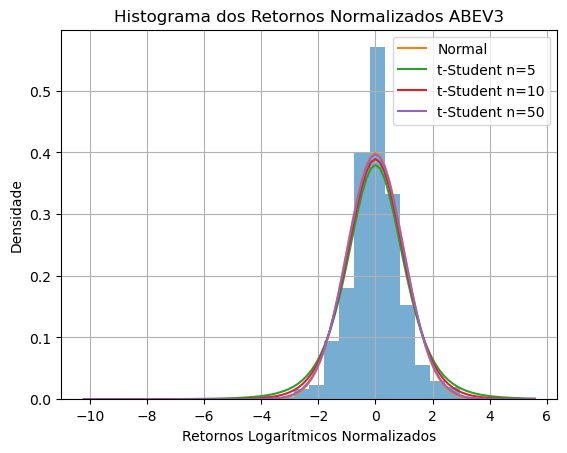

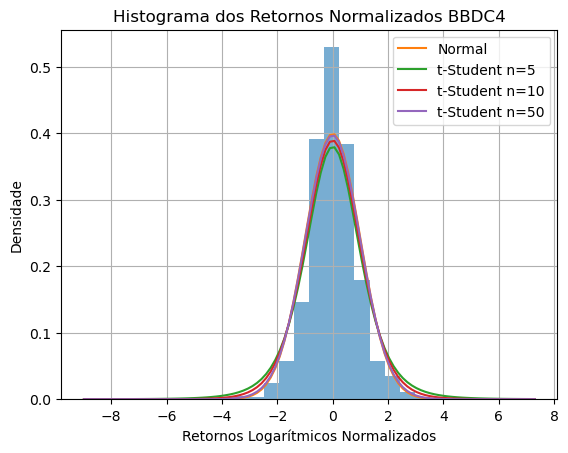

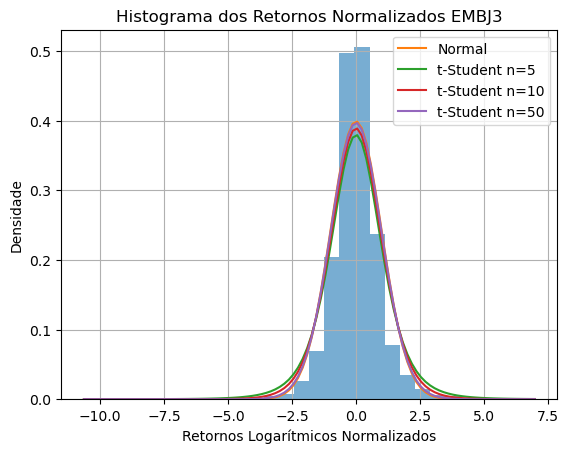

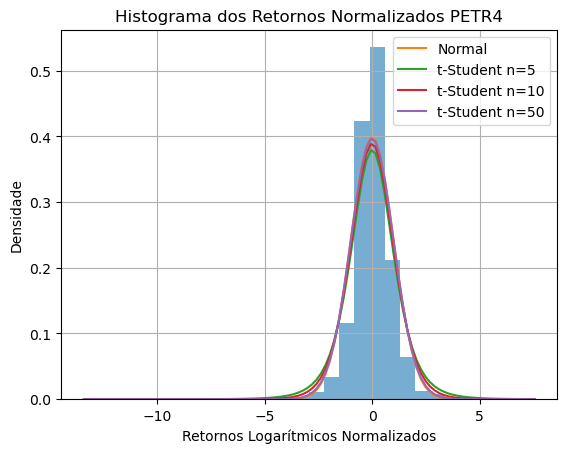

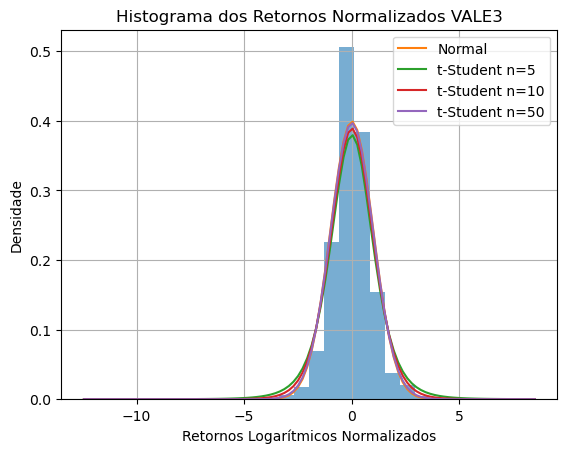

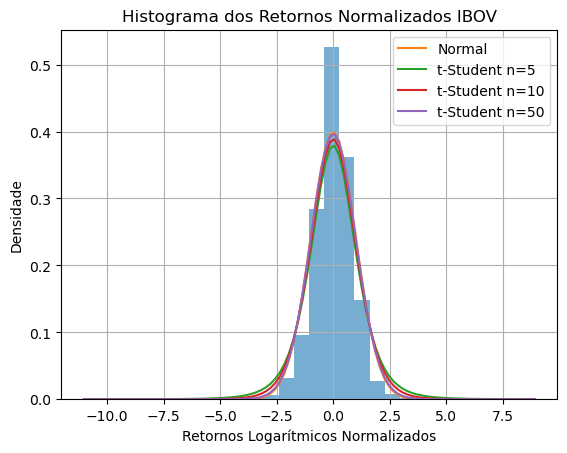

In [ ]:
### Escreva aqui seu código para responder a questão 2.
### Para responder a parte interpretativa, crie uma nova célula de texto!
for ticker in tickers:
    x = np.linspace(df2["z_score" + ticker].min(), df2["z_score" + ticker].max(), 100)
    plt.hist(df2["z_score" + ticker], bins=30, density=True, alpha=0.6)
    plt.plot(x, norm.pdf(x, 0, 1), label="Normal")
    plt.plot(x, t.pdf(x, df=5), label="t-Student n=5")
    plt.plot(x, t.pdf(x, df=10), label="t-Student n=10")
    plt.plot(x, t.pdf(x, df=50), label="t-Student n=50")
    plt.xlabel('Retornos Logarítmicos Normalizados')
    plt.ylabel('Densidade')
    plt.title('Histograma dos Retornos Normalizados ' + ticker)
    plt.legend()
    plt.grid(True)
    plt.show()

A curva gaussiana é uma distribuição teórica, já a t-student, para baixos graus de liberdade, apresenta mais kurtosis, uma maior probabilidade de ocorrência de eventos extremos, refletindo em caudas mais "gordas". Conforme os graus de liberdade da t-student aumenta, mais ela se aproxima da normal.

**Questão 03 - Considerando que os log retornos são normais, calcule a probabilidade de termos um retorno acima de 3%**

In [46]:
### Escreva aqui seu código para responder a questão 3.
### Para responder a parte interpretativa, crie uma nova célula de texto!
for ticker in tickers:
    med  = log_return[ticker].mean()
    std  = log_return[ticker].std()
    nome = ticker

    prob_acima3   = 1 - norm.cdf(0.03, med, std)

print("A probabilidade de obter um retorno acima de 3% é de " + str(round(prob_acima3*100, 2)) + "%")

A probabilidade de obter um retorno acima de 3% é de 2.13%


**Questão 04 - Plote a PDF e a CDF dos log-retornos do seu portfólio.**

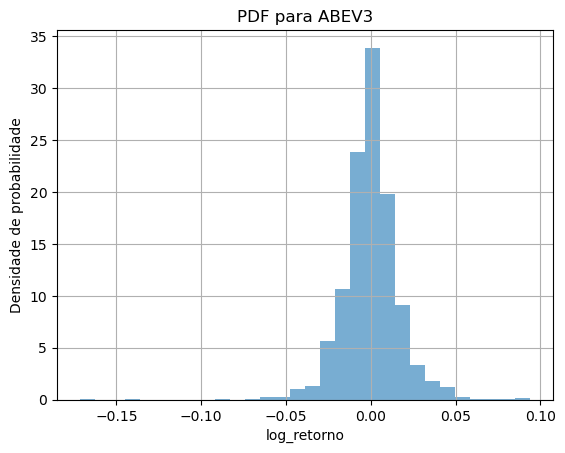

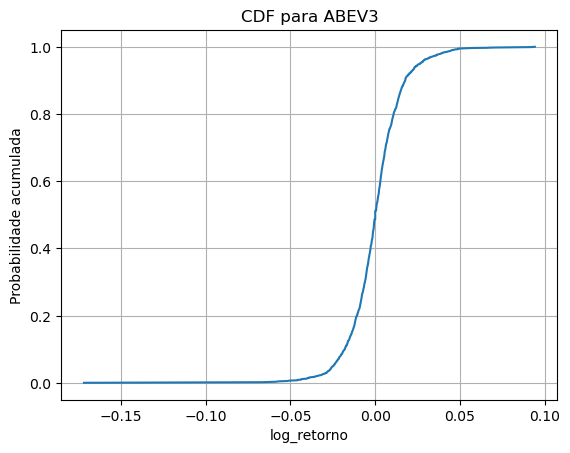

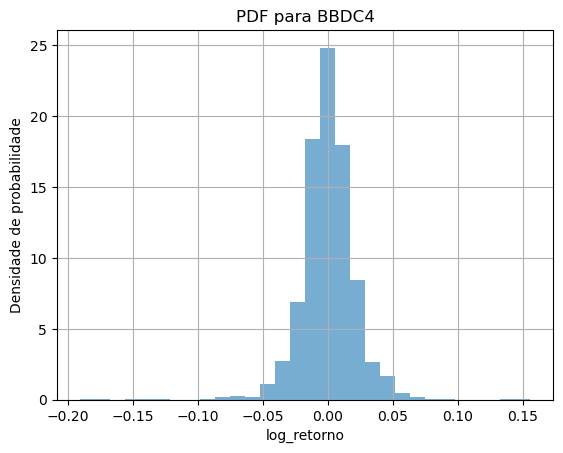

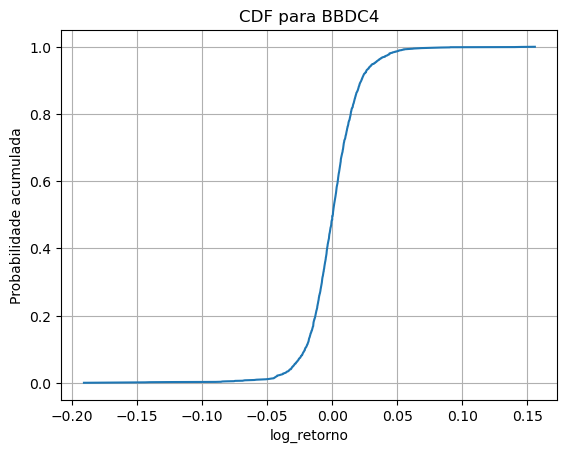

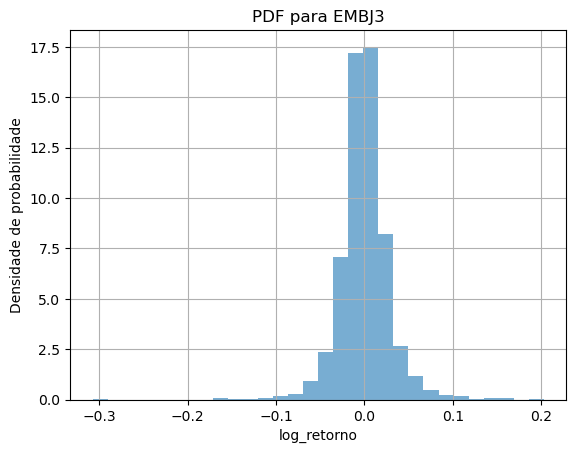

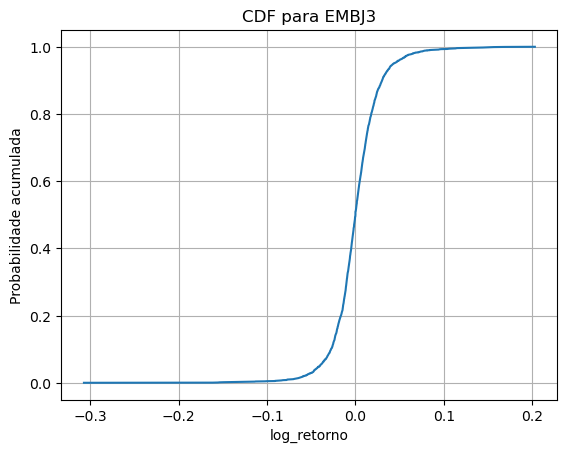

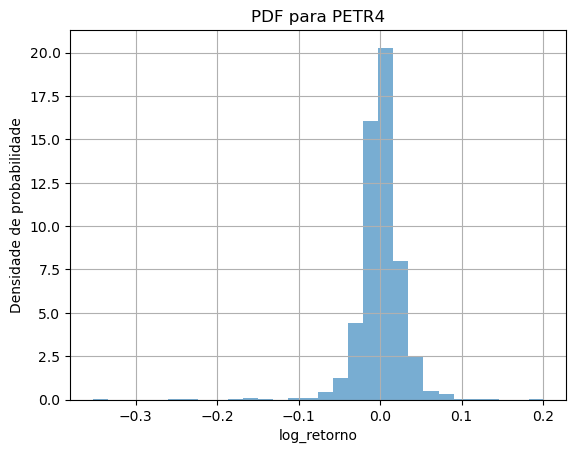

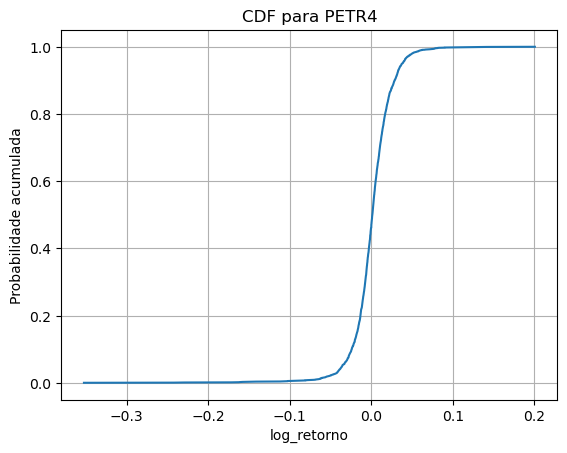

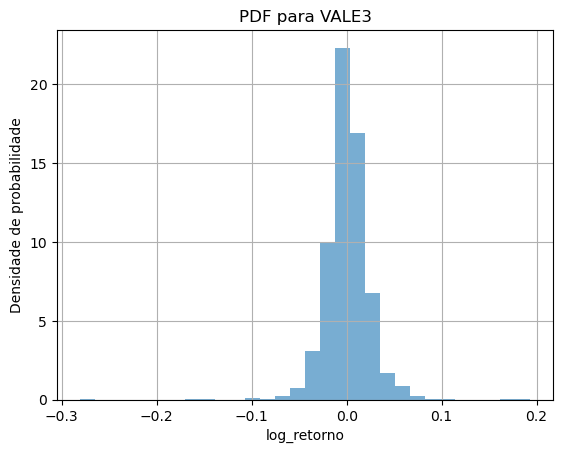

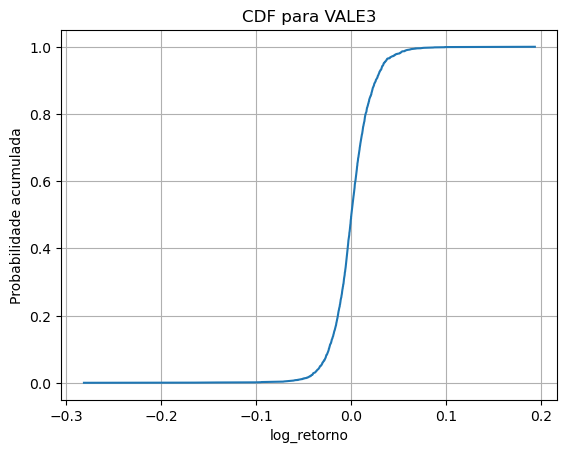

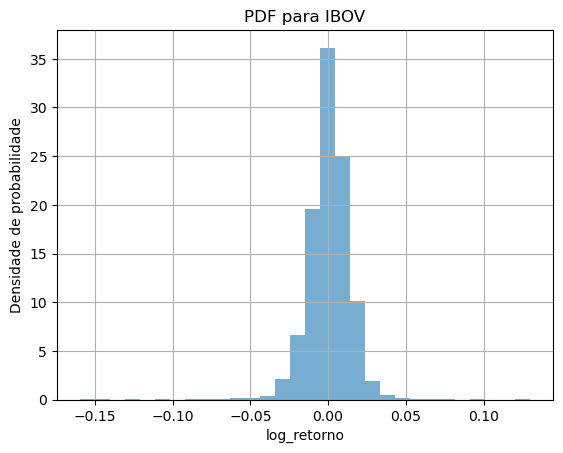

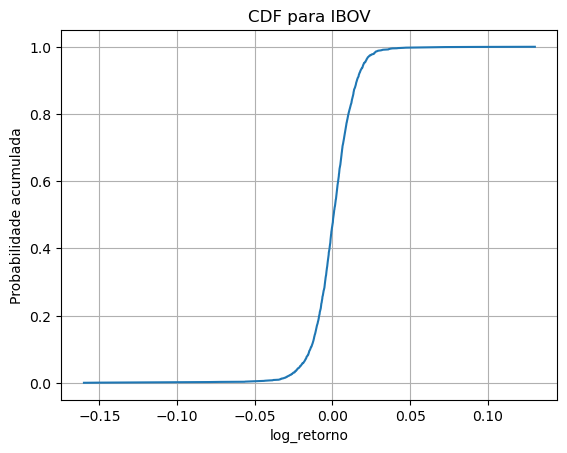

In [60]:
### Escreva aqui seu código para responder a questão 4.
### Para responder a parte interpretativa, crie uma nova célula de texto!
for ticker in tickers:
    med  = log_return[ticker].mean()
    std  = log_return[ticker].std()
    plt.hist(log_return[ticker], bins=30, density=True, alpha=0.6)
    plt.xlabel('log_retorno')
    plt.ylabel('Densidade de probabilidade')
    plt.title('PDF para ' + ticker)
    plt.grid(True)
    plt.show()
    r_sorted = np.sort(log_return[ticker])
    cdf  = np.arange(1, len(r_sorted) + 1) / len(r_sorted)
    plt.plot(r_sorted, cdf, label='CDF')
    plt.xlabel('log_retorno')
    plt.ylabel('Probabilidade acumulada')
    plt.title('CDF para ' + ticker)
    plt.grid(True)
    plt.show()

**Questão 05 - Encontre kurtosis e skewness do retornos logarítmicos do seu portfólio. Qual o significado dessas medidas? Quais são os valores para uma normal padrão e qual o significado da diferença desses valores para o seu portfólio e para uma normal padrão?**


In [16]:
### Escreva aqui seu código para responder a questão 5.
### Para responder a parte interpretativa, crie uma nova célula de texto!
for ticker in tickers:
    r = log_return[ticker]
    med  = log_return[ticker].mean()
    var  = log_return[ticker].var()
    std  = log_return[ticker].std()
    skw  = skew(log_return[ticker])
    kurt = kurtosis(log_return[ticker])
    print("skw: " + str(round(skw, 4)) + " kurt: " + str(round(kurt, 4)))

skw: -0.4477 kurt: 9.7451
skw: -0.5999 kurt: 11.6437
skw: -0.1594 kurt: 11.1339
skw: -1.9467 kurt: 25.028
skw: -0.5752 kurt: 16.5557
skw: -1.367 kurt: 20.3475


Skewness mede a simetria da distribuição. Um valor positivo indica uma cauda a direita e um valor negativo uma cauda para a esquerda, enquanto 0 demonstra simetria. Kurtosis mede a probabilidade de eventos raros, a partir da largura da cauda da distribuição. Uma normal padrão tem skewness = 0 e kurtosis = 0, já os valores do portfólio apresentam skewness negativos, indicando maior probabilidade de retornos extremos negativos e kurtosis elevada, sugerindo maior probabilidade de ocorrência de eventos raros.

**Questão 06 - Considerando que os retornos são normais, calcule o percentil 25% dos retornos e a porcentagem dos dias que teremos retornos negativos**

In [22]:
### Escreva aqui seu código para responder a questão 6.
### Para responder a parte interpretativa, crie uma nova célula de texto!

for ticker in tickers:
    med = log_return[ticker].mean()
    std = log_return[ticker].std()
    p25 = norm.ppf(0.25, med, std)
    por_negativo = norm.cdf(0, med, std)
    print([ticker], "Retorno per 25%:", str(round(p25, 4)), " Prob retorno negativo:", str(round(por_negativo, 4)))

['ABEV3'] Retorno per 25%: -0.0112  Prob retorno negativo: 0.4966
['BBDC4'] Retorno per 25%: -0.014  Prob retorno negativo: 0.4938
['EMBJ3'] Retorno per 25%: -0.0188  Prob retorno negativo: 0.4904
['PETR4'] Retorno per 25%: -0.0167  Prob retorno negativo: 0.483
['VALE3'] Retorno per 25%: -0.0145  Prob retorno negativo: 0.4855
['IBOV'] Retorno per 25%: -0.0093  Prob retorno negativo: 0.4863


**Questão 07 - O que é o máximo drawdown? Calcule o máximo drawdown do seu portfólio. Interprete o resultado.**


In [ ]:
### Escreva aqui seu código para responder a questão 7.
### Para responder a parte interpretativa, crie uma nova célula de texto!
for ticker in tickers:
    log_acumulado = np.exp(log_return[ticker].cumsum())
    pico_acumulado = log_acumulado.cummax()
    drawdown = (log_acumulado / pico_acumulado) - 1
    max_drawdown = drawdown.min() * 100
    
    print(ticker, "Máximo drawdown:", round(max_drawdown, 4), "%")

ABEV3 Máximo drawdown: -51.9898 %
BBDC4 Máximo drawdown: -52.7672 %
EMBJ3 Máximo drawdown: -77.603 %
PETR4 Máximo drawdown: -63.3561 %
VALE3 Máximo drawdown: -43.7241 %
IBOV Máximo drawdown: -46.816 %


O máximo Drawdown é a maior queda acumulada, no retorno de um ativo, a partir de um pico até o fundo seguinte. Sendo assim, demonstra o pior recuo. O maior drawdawn foi o da embraer, e em segundo lugar a Petrobrás, portanto são ativos mais expostos a quedas acentuadas no período e é consistente com o fato desse serem os ativos mais voláteis. Já o menor drawdawn foi da vale, demonstrando uma maior estabilidade.

**Questão 08 - Teste se os retornos do portfólio são estatisticamente diferentes de zero e do retorno do índice BOVESPA. Qual alpha você utilizaria?**

In [70]:
### Escreva aqui seu código para responder a questão 8.
### Para responder a parte interpretativa, crie uma nova célula de texto!
alpha     = 0.05
z_critico = norm.ppf(1 - alpha / 2)

print("H0: retornos = 0 e Ha: retornos != 0")
for ticker in tickers:
    r    = log_return[ticker]
    n    = len(r)
    med  = r.mean()
    std  = r.std()
    ep   = std / np.sqrt(n)
    z    = med / ep
    pval = 2 * (1 - norm.cdf(abs(z)))
    if pval <= alpha:
        print([ticker], "Média =", str(round(med, 5)), "Erro padrão =", str(round(ep, 3)), "z =", str(round(z, 3)), "p valor =", str(round(pval, 4)), "Decisão: Rejeita H₀")
    else:
        print([ticker], "Média =", str(round(med, 6)), "Erro padrão =", str(round(ep, 3)), "z =", str(round(z, 3)), "p valor =", str(round(pval, 4)), "Decisão: Não rejeita H₀")

print(" ")
print("H0: retornos = retorno do IBOV e Ha: retornos != retorno do IBOV")
for ticker in tickers:
    r    = log_return[ticker]
    r_ibov = log_return['IBOV']
    diff = r - r_ibov
    n    = len(diff)
    med  = diff.mean()
    std  = diff.std()
    ep   = std / np.sqrt(n)
    z    = med / ep
    pval = 2 * (1 - norm.cdf(abs(z)))
    if pval <= alpha:
        print([ticker], "Média =", str(round(med, 5)), "Erro padrão =", str(round(ep, 3)), "z =", str(round(z, 3)), "p valor =", str(round(pval, 4)), "Decisão: Rejeita H₀")
    else:
        print([ticker], "Média =", str(round(med, 6)), "Erro padrão =", str(round(ep, 3)), "z =", str(round(z, 3)), "p valor =", str(round(pval, 4)), "Decisão: Não rejeita H₀")



H0: retornos = 0 e Ha: retornos != 0
['ABEV3'] Média = 0.000142 Erro padrão = 0.0 z = 0.405 p valor = 0.6856 Decisão: Não rejeita H₀
['BBDC4'] Média = 0.000332 Erro padrão = 0.0 z = 0.746 p valor = 0.4557 Decisão: Não rejeita H₀
['EMBJ3'] Média = 0.000699 Erro padrão = 0.001 z = 1.157 p valor = 0.2474 Decisão: Não rejeita H₀
['PETR4'] Média = 0.00113 Erro padrão = 0.001 z = 2.042 p valor = 0.0412 Decisão: Rejeita H₀
['VALE3'] Média = 0.000824 Erro padrão = 0.0 z = 1.74 p valor = 0.0818 Decisão: Não rejeita H₀
['IBOV'] Média = 0.0005 Erro padrão = 0.0 z = 1.644 p valor = 0.1002 Decisão: Não rejeita H₀
 
H0: retornos = retorno do IBOV e Ha: retornos != retorno do IBOV
['ABEV3'] Média = -0.000357 Erro padrão = 0.0 z = -1.16 p valor = 0.246 Decisão: Não rejeita H₀
['BBDC4'] Média = -0.000168 Erro padrão = 0.0 z = -0.597 p valor = 0.5507 Decisão: Não rejeita H₀
['EMBJ3'] Média = 0.000199 Erro padrão = 0.001 z = 0.375 p valor = 0.708 Decisão: Não rejeita H₀
['PETR4'] Média = 0.000626 Erro pa

/var/folders/b_/j1j9jl8d5q5205nq8fkb3lz00000gn/T/ipykernel_67796/1962419427.py:30: RuntimeWarning: invalid value encountered in scalar divide
  z    = med / ep


O alpha utilizado foi de 5%, por ser o nível de significância mais usual em testes estatísticos. Isso implica uma probabilidade de 5% de rejeitar incorretamente a hipótese nula e, portanto, um nível de confiança de 95%.